# 4B - FM IQ Demod (FIR-Lowpass)

Dieses Notebook ist die Variante von `4-FM-IQ-demod.ipynb` mit einem **höherwertigen FIR-Tiefpass** nach der komplexen Heruntermischung (anstelle des einfachen Sliding-Averagers).

## Überblick und Formeln

Eingelesenes Realsignal:
$$s[n] = \Re\{z_{mix}[n]\}$$

Komplexer LO:
$$z_{LO}[n] = \cos(2\pi f_{LO} n/f_s) + j\sin(2\pi f_{LO} n/f_s)$$

Komplexes Heruntermischen:
$$u[n] = s[n] \cdot e^{-j2\pi f_{LO} n/f_s}$$

FIR-Tiefpass:
$$z_{bb}[n]=(u*h_{FIR})[n]$$

FM-Diskriminator:
$$d[n]=z_{bb}[n]z^*_{bb}[n-1],\quad y[n]=\angle\{d[n]\}$$

## Parameter und Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display
from scipy.signal import firwin

N_fft = 16384
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'
t_plot_ms = 6.0

## 1) Signal laden (nur I-Kanal)

Das gespeicherte Signal kann komplex sein; für diese Demodulationskette wird gezielt der Realteil als Eingang verwendet:
$$s[n]=\Re\{z[n]\}$$

In [2]:
in_path = Path.cwd() / 'FM-IQ-carrier.npy'
meta_path = Path.cwd() / 'FM-IQ-carrier-meta.npy'

z_in = np.load(in_path)
meta = np.load(meta_path, allow_pickle=True).item() if meta_path.exists() else {}

fs = float(meta.get('fs_hz', 48_000.0))
f_carrier_eff = float(meta.get('f_out_center_hz', meta.get('f_lo_hz', 10_000.0)))
f_m = float(meta.get('f_m_hz', 1_000.0))

s = np.real(z_in).astype(np.float64)
N = len(s)
t = np.arange(N) / fs
n_plot = min(N, int(t_plot_ms * 1e-3 * fs))

print(f'Geladen: {in_path}')
print(f'Samples: {N}, fs={fs:.1f} Hz, f_carrier_eff(meta)={f_carrier_eff:.1f} Hz, f_m(meta)={f_m:.1f} Hz')

Geladen: C:\Users\julia\KT-course\lab_suite\labs\04_03_LABOR-5\submissions\FM-IQ-carrier.npy
Samples: 200000, fs=200000.0 Hz, f_carrier_eff(meta)=-22000.0 Hz, f_m(meta)=880.0 Hz


## 2) Komplexe Heruntermischung

$$u[n] = s[n]\cdot e^{-j(2\pi f_{demod}n/f_s + \varphi_{demod})}$$

In [3]:
f_demod_lo = f_carrier_eff
phi_demod = 0.0

lo_cx = np.exp(-1j * (2*np.pi*f_demod_lo*t + phi_demod))
u_mix = s * lo_cx

print(f'f_demod_lo = {f_demod_lo:.1f} Hz')

f_demod_lo = -22000.0 Hz


## 2a) FIR-Tiefpass nach der komplexen Mischung

Statt eines gleitenden Mittelwerts verwenden wir einen konfigurierbaren FIR-Filter (Finite Impulse Response):

$$z_{bb}[n] = (u * h_{FIR})[n]$$

Vorteile:
- steilere und kontrollierbare Filtercharakteristik
- gut reproduzierbar über Tap-Anzahl/Fenster/Cutoff

Konfigurierbare Parameter unten:
- `FIR_NUM_TAPS`: Filterordnung/Taplänge (ungerade empfohlen)
- `FIR_CUTOFF_HZ`: Grenzfrequenz
- `FIR_WINDOW`: Fensterfunktion für FIR-Design
- `FIR_APPLY_MODE`: Faltungsmodus (`same` etc.)

In [4]:
# FIR-Parameter (anpassbar)
FIR_NUM_TAPS = 201          # Anzahl Taps (ungerade empfohlen)
FIR_CUTOFF_HZ = max(5 * f_m, 400.0)
FIR_WINDOW = 'hamming'      # z.B. 'hamming', 'hann', 'blackman'
FIR_APPLY_MODE = 'same'     # 'full' | 'same' | 'valid'

# FIR-Design (normierte Grenzfrequenz)
nyq = 0.5 * fs
cutoff_norm = min(max(FIR_CUTOFF_HZ / nyq, 1e-6), 0.999)
num_taps = int(FIR_NUM_TAPS)
if num_taps % 2 == 0:
    num_taps += 1

h_fir = firwin(num_taps, cutoff=cutoff_norm, window=FIR_WINDOW, pass_zero='lowpass')

# Filter auf I/Q getrennt anwenden
i_filt = np.convolve(np.real(u_mix), h_fir, mode=FIR_APPLY_MODE)
q_filt = np.convolve(np.imag(u_mix), h_fir, mode=FIR_APPLY_MODE)
z_bb = i_filt + 1j * q_filt

if FIR_APPLY_MODE != 'same':
    t = np.arange(len(z_bb)) / fs
    n_plot = min(len(z_bb), int(t_plot_ms * 1e-3 * fs))

I_bb = np.real(z_bb)
Q_bb = np.imag(z_bb)

print(
    f'FIR aktiv: taps={num_taps}, cutoff={FIR_CUTOFF_HZ:.1f} Hz, '
    f'window={FIR_WINDOW}, mode={FIR_APPLY_MODE}'
)

FIR aktiv: taps=201, cutoff=4400.0 Hz, window=hamming, mode=same


## 2b) Zeitbereichsplots (Eingang + rekonstruierte I/Q-Kanäle)

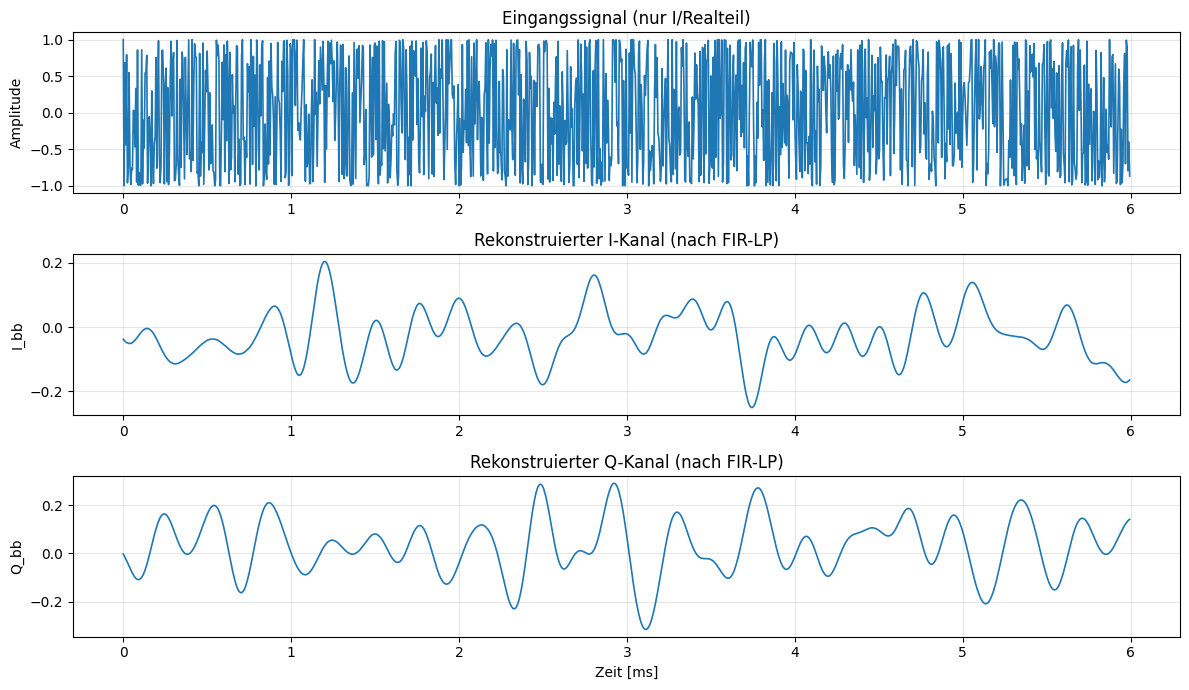

In [5]:
plt.figure(figsize=(12, 7))

plt.subplot(3,1,1)
plt.plot(1e3*t[:n_plot], s[:n_plot], lw=1.2)
plt.title('Eingangssignal (nur I/Realteil)')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)

plt.subplot(3,1,2)
plt.plot(1e3*t[:n_plot], I_bb[:n_plot], lw=1.2)
plt.title('Rekonstruierter I-Kanal (nach FIR-LP)')
plt.ylabel('I_bb')
plt.grid(alpha=0.3)

plt.subplot(3,1,3)
plt.plot(1e3*t[:n_plot], Q_bb[:n_plot], lw=1.2)
plt.title('Rekonstruierter Q-Kanal (nach FIR-LP)')
plt.xlabel('Zeit [ms]')
plt.ylabel('Q_bb')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2c) Spektren (direkt nach den Zeitplots)

Zweiseitige Darstellung mit optionaler Fensterung.

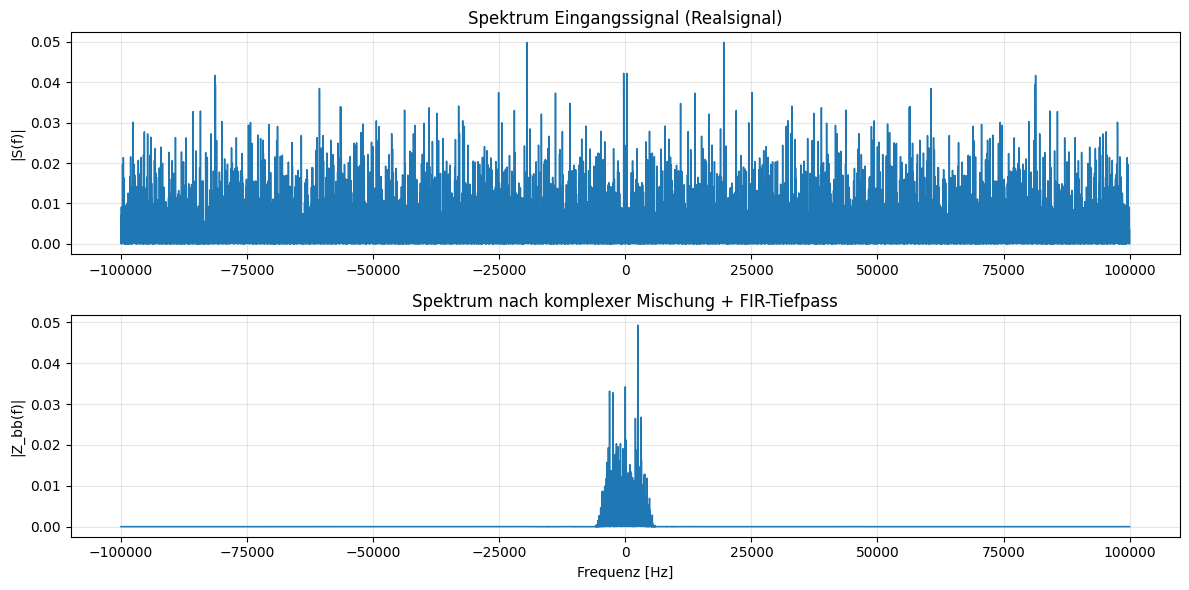

In [6]:
def _window_for_fft(N, kind='hann'):
    k = (kind or 'rect').lower()
    if k == 'hann':
        return np.hanning(N)
    if k == 'hamming':
        return np.hamming(N)
    return np.ones(N)

def spectrum_mag_two_sided(x, fs, N_fft, use_window=True, window_kind='hann'):
    x = np.asarray(x)
    N = len(x)
    N_use = min(N, N_fft)
    x_use = x[:N_use]

    if use_window:
        w = _window_for_fft(N_use, window_kind)
    else:
        w = np.ones(N_use)

    cg = np.mean(w)
    X = np.fft.fftshift(np.fft.fft(x_use * w, n=N_fft))
    A = np.abs(X) / max(N_use * cg, 1e-12)
    f = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
    return f, A

f_s, A_s = spectrum_mag_two_sided(s, fs, N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)
f_bb, A_bb = spectrum_mag_two_sided(z_bb, fs, N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(f_s, A_s, lw=1.1)
plt.title('Spektrum Eingangssignal (Realsignal)')
plt.ylabel('|S(f)|')
plt.grid(alpha=0.3)

plt.subplot(2,1,2)
plt.plot(f_bb, A_bb, lw=1.1)
plt.title('Spektrum nach komplexer Mischung + FIR-Tiefpass')
plt.xlabel('Frequenz [Hz]')
plt.ylabel('|Z_bb(f)|')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3) FM-Demodulation aus rekonstruierter IQ-Folge

$$d[n] = z_{bb}[n]z^*_{bb}[n-1],\quad u_{demod}[n]=\angle(d[n])$$

Anschließend folgt eine Glättung (einfache Nachfilterung).

In [7]:
d = z_bb[1:] * np.conj(z_bb[:-1])
fm_disc = np.angle(d)

# einfache Nachfilterung auf dem Demodsignal
N_win_demod = max(5, int(np.round(0.002 * fs)))
if N_win_demod % 2 == 0:
    N_win_demod += 1
h_demod = np.ones(N_win_demod) / N_win_demod
u_demod = np.convolve(fm_disc, h_demod, mode='same')

print(f'Demod-Nachfilter: N_win_demod = {N_win_demod}')

Demod-Nachfilter: N_win_demod = 401


## 3a) Demodulationsplots

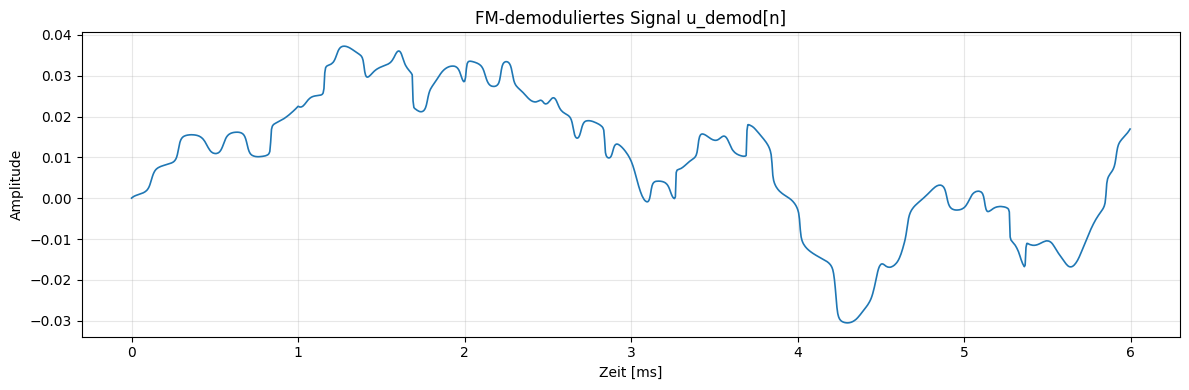

In [8]:
t_demod = np.arange(len(u_demod)) / fs
n_plot_demod = min(len(u_demod), int(t_plot_ms * 1e-3 * fs))

plt.figure(figsize=(12, 4))
plt.plot(1e3*t_demod[:n_plot_demod], u_demod[:n_plot_demod], lw=1.2)
plt.title('FM-demoduliertes Signal u_demod[n]')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4) Audiofeedback

In [9]:
# Audio-Parameter (für Studenten leicht anpassbar)
fs_audio = 48_000
start_s = 1.0
duration_s = 5.0

In [10]:
# 3) Audio vorbereiten und inline abspielen (48 kS/s)
# verwendet fs_audio, start_s, duration_s aus der vorherigen Parameterzelle


# einfache lineare Resampling-Näherung ohne Zusatzbibliothek
duration = len(u_demod) / fs
n_audio = int(duration * fs_audio)
t_src = np.arange(len(u_demod)) / fs
t_dst = np.arange(n_audio) / fs_audio
x_audio = np.interp(t_dst, t_src, u_demod)

# DC entfernen + normieren
x_audio = x_audio - np.mean(x_audio)
x_audio = x_audio / max(np.max(np.abs(x_audio)), 1e-12)

# zyklisch wiederholen, damit mehrere Sekunden hörbar sind
#duration_s = 4.0
rep = max(1, int(np.ceil((duration_s * fs_audio) / len(x_audio))))
#rep = 4
x_audio_rep = np.tile(x_audio, rep)
x_audio_rep = x_audio_rep[:int(duration_s * fs_audio)]

print(f'Audio vorbereitet: samples read: {len(u_demod)} Originaldauer {duration_s} sec x_audio_len={len(x_audio)} rep={rep} len(x_audio_rep)={len(x_audio_rep)} Samples @ {fs_audio} Hz, Dauer {len(x_audio_rep)/fs_audio:.2f} s')
display(Audio(x_audio_rep, rate=fs_audio))

Audio vorbereitet: samples read: 199999 Originaldauer 5.0 sec x_audio_len=47999 rep=6 len(x_audio_rep)=240000 Samples @ 48000 Hz, Dauer 5.00 s
